# **Reproduction: Landscapes of Crashes (Gidea & Katz, 2018)**

This notebook reproduces the empirical benchmarks and financial market crash analyses from Gidea & Katz (2018), evaluating the application of persistence landscapes to detect structural phase transitions and early warning signals (EWS) in dynamic systems. We benchmark $L^1$ and $L^2$ landscape norms against synthetic white noise variance (Section 3.3) and a simulated system state transition (Section 3.4). We then apply the delay-embedded topological pipeline to US stock market index returns leading up to the 2000 Dot-Com Bubble Crash and 2008 Lehman Bankruptcy (Section 4), evaluating Critical Slowing Down (CSD) indicators alongside the market volatility index (VIX). Finally, we take a detour and investigate the use of persistence images (Adams 2017) as an alternative to persistence landscapes.

In [1]:
from utils import (
    generate_white_noise_dataset, generate_gamma_transition_dataset, min_max_scale, get_1000_days_prior,
    kendall_report, compute_indicators
)

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='white', rc={'axes.grid': False})
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.alpha'] = 0.0

import sys
import os
sys.path.append(os.path.abspath('../..'))

from core.representations import pc_landscape_norms
from core.time_series import compute_time_series_landscape_norms

colors = sns.color_palette("bright")
random_seed = 42
inspect_output = True

## **Relationship between PL Norms and White Noise Variance (Section 3.3)**

For our first benchmark, we test whether **Persistence Landscape (PL)** norms are strictly proportional to the variance of multidimensional white noise. 

Given a persistence diagram $D = \{(b_i, d_i)\}_{i \in I}$, the piecewise linear functions $f_{(b,d)}(t)$ are defined as:
$$f_{(b,d)}(t) = \begin{cases} t - b & \text{if } b \le t \le \frac{b+d}{2} \\ d - t & \text{if } \frac{b+d}{2} < t \le d \\ 0 & \text{otherwise} \end{cases}$$
The $k$-th persistence landscape $\lambda_k(t)$ corresponds to the $k$-th largest value of $\{f_{(b,d)}(t)\}_{(b,d) \in D}$. The $L^p$ norm of the landscape is computed as:
$$\|\lambda\|_p = \left( \sum_{k=1}^\infty \int_{\mathbb{R}} |\lambda_k(t)|^p \, dt \right)^{1/p}$$

Geometrically, scaling a point cloud $X \mapsto cX$ expands birth and death scales proportionally $(b, d) \mapsto (cb, cd)$, stretching feature persistence linearly. Consequently, higher variance increases average pairwise point distances, resulting in a proportional growth of $\|\lambda\|_1$ and $\|\lambda\|_2$.

The experiment was reproduced by using the following parameters:
1. **Standard Deviations**: Grid from $\sigma = 1.0$ to $\sigma = 10.0$ in 10 uniform increments.
2. **Point Cloud Specification**: $N = 100$ normally distributed points in $\mathbb{R}^4$ with variance of $(\sigma + \delta_i)^2$ where $\delta_i \in [-0.1, 0.1]$ is sampled.
3. **Monte Carlo Simulations**: $1,000$ independent realizations computed per variance level to compute mean $L^1$ and $L^2$ norms over $H_1$.

To reduce the amount of code, we create a helper function `pc_landscape_norms` in `core/representations.py`. Given a point cloud, it computes the Rips filtration, extracts persistence pairs up to dimension $k$, converts the persistence diagram to a landscape, and returns the $L^1$, $L^2$ norms.



In [2]:
realizations = 1000
sigma_range = np.linspace(1.0, 10.0, 10)
mc_data = generate_white_noise_dataset(sigma_values=sigma_range, num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
mc_t_interval = np.linspace(0, 25.0, 1000)

p1_matrix = np.zeros((realizations, len(sigma_range)))
p2_matrix = np.zeros((realizations, len(sigma_range)))
for j, sigma in enumerate(sigma_range):
    for i, arr in enumerate(mc_data[sigma]):
        p1, p2 = pc_landscape_norms(arr, mc_t_interval)
        p1_matrix[i,j] = p1
        p2_matrix[i,j] = p2

p1_norms = np.mean(p1_matrix, axis=0)
p2_norms = np.mean(p2_matrix, axis=0)

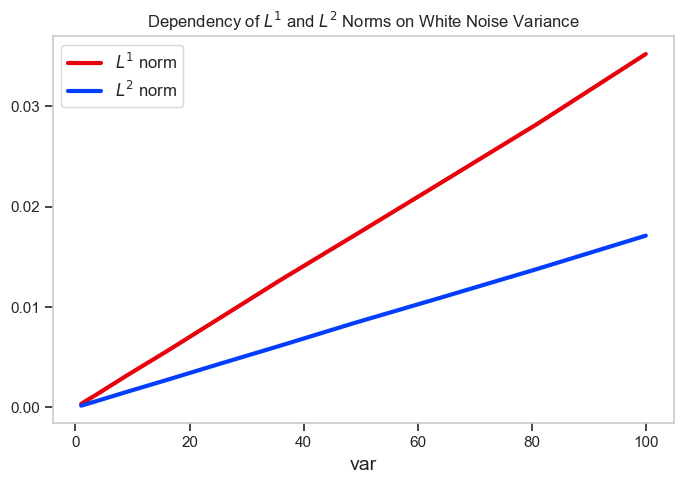

In [3]:
variances = sigma_range ** 2

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(variances, p1_norms, color=colors[3], linewidth=3, label='$L^1$ norm')
ax.plot(variances, p2_norms, color=colors[0], linewidth=3, label='$L^2$ norm')

ax.set_xlabel('var', fontsize=14)
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.tick_params(bottom=True, left=True, length=6, width=1.2)
ax.set_title(r'Dependency of $L^1$ and $L^2$ Norms on White Noise Variance', fontsize=12)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

The reproduction results match the paper's findings. Both $L^1$ and $L^2$ persistence landscape norms exhibit a strong linear dependency on white noise variance ($\sigma^2$). This confirms that the norms act as an effective quantitative proxy for variance within a point cloud.

## **Relationship between PL Norms and System State (Section 3.4)**

In complex dynamical systems, a phase transition from a stable (*cool*) state to a critical/turbulent (*heated*) state is often preceded by increasing variance across system state variables. We simulate a dynamic system transitioning through a critical threshold to evaluate whether PL norms can track phase transitions geometrically.

Implementation in code:
1. **Time Steps**: $T = 100$ sequential time steps ($t \in [1, 100]$).
2. **Cool Phase ($t \le 75$)**: Point clouds sampled from a Gamma distribution with constant shape parameter $\alpha = 8.0$, representing a steady system state with constant variance.
3. **Transition Phase ($t > 75$)**: The shape parameter decays linearly according to $\alpha(t) = 8.0 - 0.25(t - 74)$, triggering a spike in point cloud variance.
4. **Realizations**: $100$ Monte Carlo simulation runs, evaluating normalized average variance against normalized $H_1$ landscape norms across $N=100$ points in $\mathbb{R}^4$.

In [4]:
realizations = 100
steps = 100
gm_data = generate_gamma_transition_dataset(num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
gm_t_interval = np.linspace(0, 5.0, 1000)

p1_matrix = np.zeros((realizations, steps))
p2_matrix = np.zeros((realizations, steps))
var_matrix = np.zeros((realizations, steps))

for r in range(realizations):
    for s in range(steps):
        arr = gm_data[r][s]
        p1, p2 = pc_landscape_norms(arr, gm_t_interval)
        p1_matrix[r, s] = p1
        p2_matrix[r, s] = p2
        var_matrix[r, s] = np.mean(np.var(arr, axis=0))

p1_mean = np.mean(p1_matrix, axis=0)
p2_mean = np.mean(p2_matrix, axis=0)
avg_variance = np.mean(var_matrix, axis=0)

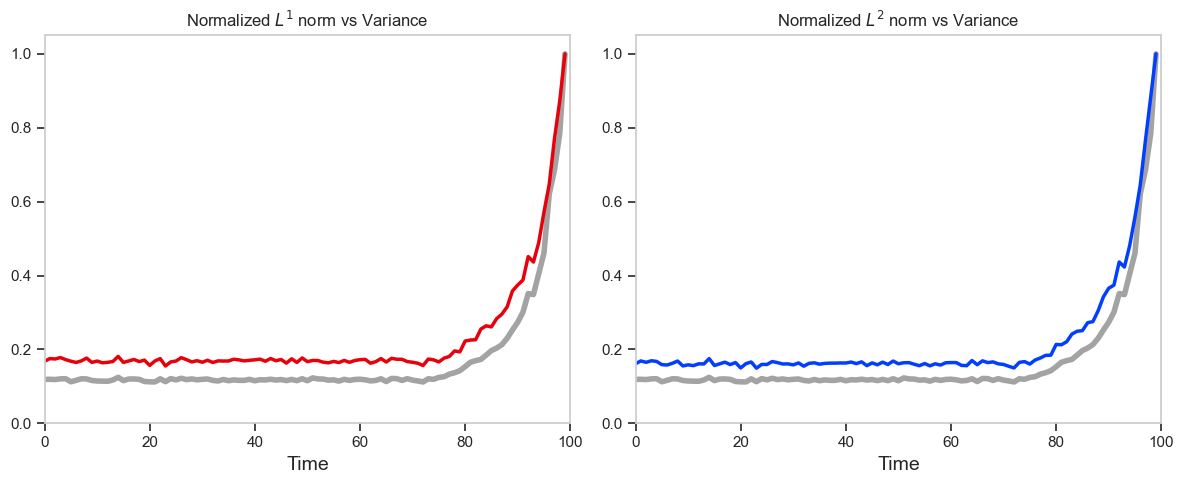

In [5]:
p1_normalized = p1_mean / np.max(p1_mean)
p2_normalized = p2_mean / np.max(p2_mean)
var_normalized = avg_variance / np.max(avg_variance)

time_steps = np.arange(0, steps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax1.plot(time_steps, p1_normalized, color=colors[3], linewidth=2.5, zorder=2, label='Normalized $L^1$-norm')
ax1.set_xlabel('Time', fontsize=14)
ax1.set_xlim(0, 100)
ax1.set_ylim(0.0, 1.05)
ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.set_title(r'Normalized $L^1$ norm vs Variance', fontsize=12)

ax2.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax2.plot(time_steps, p2_normalized, color=colors[0], linewidth=2.5, zorder=2, label='Normalized $L^2$-norm')
ax2.set_xlabel('Time', fontsize=14)
ax2.set_xlim(0, 100)
ax2.set_ylim(0.0, 1.05)
ax2.yaxis.set_major_locator(MultipleLocator(0.2))
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.set_title(r'Normalized $L^2$ norm vs Variance', fontsize=12)

plt.tight_layout()
plt.show()

The simulated transition results match the original paper. During the stable phase ($t \le 75$), both $L^1$ and $L^2$ landscape norms remain flat near baseline levels. As soon as the system enters the transition phase ($t > 75$), the norms increase rapidly together with the point cloud variance. This demonstrates that PL norms can effectively signal structural phase shifts in dynamic state spaces.

## **Using PL Norms to Analyse Financial Time Series Data (Section 4)**

We apply the topological framework to historical US equity markets to investigate structural geometric changes prior to major financial crises.

#### **Data Preprocessing and General Analysis**
We retrieve daily closing prices $P_i(t)$ for four US financial market indices:
1. **S&P 500**: Benchmark broad-market equity index.
2. **Dow Jones Industrial Average**: Blue-chip industrial stock index.
3. **NASDAQ Composite**: Tech-heavy equity index.
4. **Russell 2000**: Small-cap market index.

Daily logarithmic returns $r_i(t) = \ln(P_i(t) / P_i(t-1))$ are computed across all four indices to construct daily 4D return vectors. Sliding time windows of length $w \in \{50, 100\}$ trading days are slid across the time series, constructing point clouds to track the evolving topology of market returns over time.

In [6]:
data = yf.download(
    ['^GSPC', '^DJI', '^IXIC', '^RUT'], start='1987-12-23', end='2016-12-09', progress=False
)

df_close = data['Close']

df = df_close.rename(
    columns={
        '^DJI': 'DJIA',
        '^GSPC': 'SP500',
        '^IXIC': 'NASDAQ',
        '^RUT': 'RUSSELL2000',
    }
)

print(df.head(3))
print(f"\n{df.count()}")

Ticker      DJIA       SP500      NASDAQ  RUSSELL2000
Date                                                 
1987-12-23   NaN  253.160004  331.500000   120.800003
1987-12-24   NaN  252.029999  333.200012   121.589996
1987-12-28   NaN  245.570007  325.600006   119.000000

Ticker
DJIA           6284
SP500          7301
NASDAQ         7301
RUSSELL2000    7301
dtype: int64


Note that historical DJIA price data prior to 1992 is missing in `yfinance`. Since this data is outside the primary evaluation scope, we restrict our analysis to the period from **January 1st, 1992 to December 9th, 2016** ($N = 6,284$ trading days).

We start by computing $L^1$ and $L^2$ PL norms across the full time horizon (1992–2016) using both sliding windows to locate macro-level topological spikes around major market events. To do so, we create a new function `compute_time_series_landscape_norms` in `core/time_series.py`.

In [7]:
returns_df = np.log(df / df.shift(1)).dropna()

returns = returns_df.values
dates = returns_df.index

window_size = [50, 100]

# ASSUMPTION / PROXY
t_interval = np.linspace(0, 0.1, 1000)

(p1_50days, p2_50days), (p1_100days, p2_100days) = compute_time_series_landscape_norms(returns, window_size, t_interval)

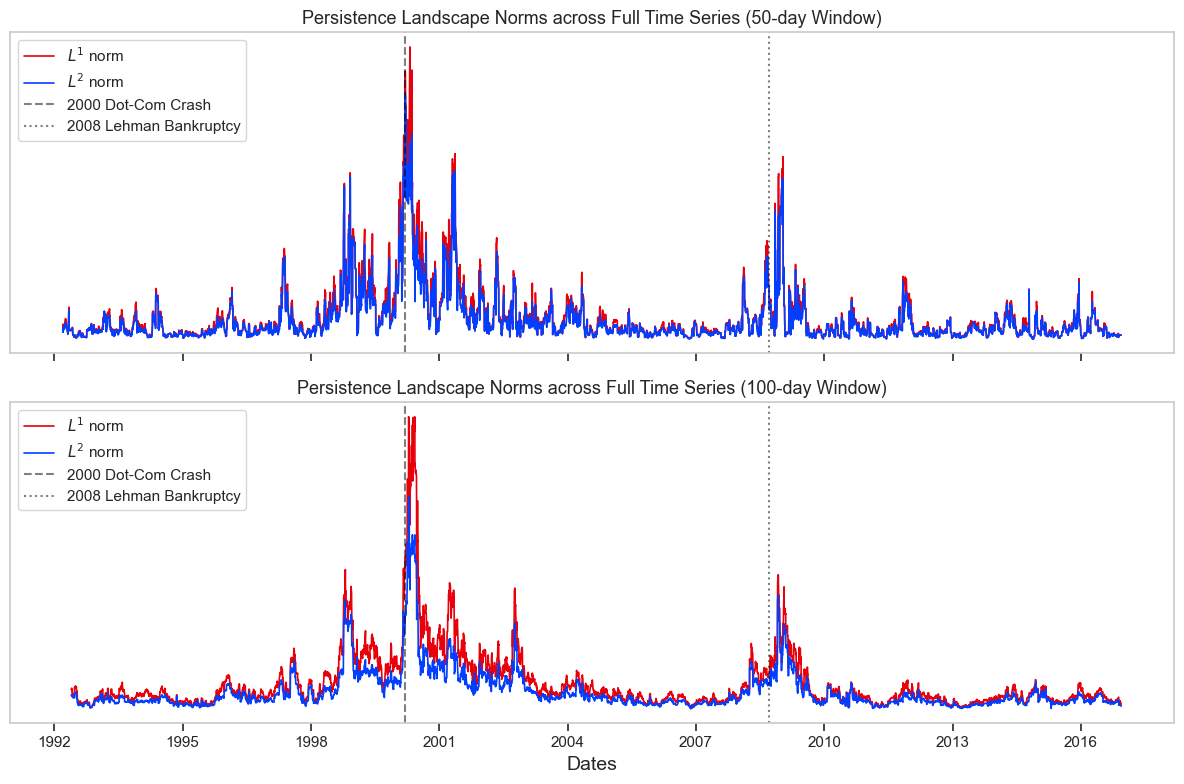

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(
    dates[50:],
    p1_50days,
    color=colors[3],
    linewidth=1.2,
    label='$L^1$ norm',
)

ax1.plot(
    dates[50:],
    p2_50days,
    color=colors[0],
    linewidth=1.2,
    label='$L^2$ norm',
)

ax1.axvline(
    x=pd.Timestamp('2000-03-10'),
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.5,
    label='2000 Dot-Com Crash',
)
ax1.axvline(
    x=pd.Timestamp('2008-09-15'),
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.5,
    label='2008 Lehman Bankruptcy',
)

ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.set_yticks([])
ax1.set_title(
    'Persistence Landscape Norms across Full Time Series (50-day Window)',
    fontsize=13,
)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax1.legend(fontsize=11, loc='upper left')


ax2.plot(
    dates[100:],
    p1_100days,
    color=colors[3],
    linewidth=1.2,
    label='$L^1$ norm',
)

ax2.plot(
    dates[100:],
    p2_100days,
    color=colors[0],
    linewidth=1.2,
    label='$L^2$ norm',
)

ax2.axvline(
    x=pd.Timestamp('2000-03-10'),
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.5,
    label='2000 Dot-Com Crash',
)
ax2.axvline(
    x=pd.Timestamp('2008-09-15'),
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.5,
    label='2008 Lehman Bankruptcy',
)

ax2.set_xlabel('Dates', fontsize=14)
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.set_yticks([])
ax2.set_title(
    'Persistence Landscape Norms across Full Time Series (100-day Window)',
    fontsize=13,
)

ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

Overall, we observe that the 50-day window exhibits greater dispersion, yet their norms follow each other more closely. It is also evident that the topology changes significantly before/during extreme market shocks.

#### **Deeper Analysis: Dot-Com Crash**

To evaluate the changes in topology prior to an extreme event, we extract the period from October 1996 to April 2000 surrounding the Dot-Com Bubble collapse and compare $L^1$ and $L^2$ landscape norms across $w = 50$ and $w = 100$ trading days.

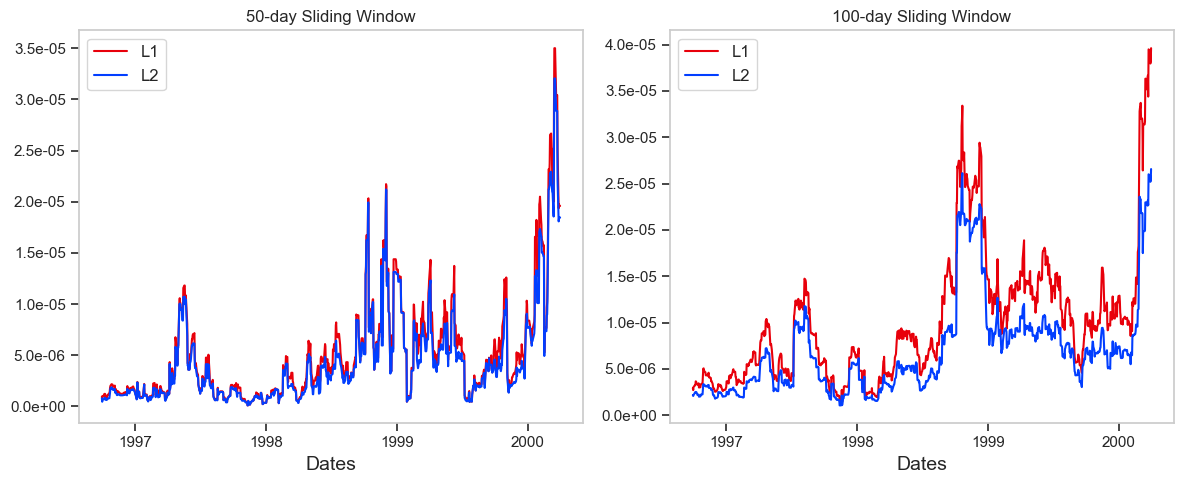

In [9]:
dates_50 = dates[50:]
mask_50 = (dates_50 >= '1996-10-01') & (dates_50 <= '2000-04-01')

sub_dates_50 = dates_50[mask_50]
sub_p1_50 = p1_50days[mask_50]
sub_p2_50 = p2_50days[mask_50]

dates_100 = dates[100:]
mask_100 = (dates_100 >= '1996-10-01') & (dates_100 <= '2000-04-01')

sub_dates_100 = dates_100[mask_100]
sub_p1_100 = p1_100days[mask_100]
sub_p2_100 = p2_100days[mask_100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(sub_dates_50, sub_p1_50, color=colors[3], linewidth=1.5, label='L1')
ax1.plot(sub_dates_50, sub_p2_50, color=colors[0], linewidth=1.5, label='L2')
ax1.set_xlabel('Dates', fontsize=14)
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title('50-day Sliding Window', fontsize=12)
ax1.legend(fontsize=12, loc='upper left')

ax2.plot(sub_dates_100, sub_p1_100, color=colors[3], linewidth=1.5, label='L1')
ax2.plot(sub_dates_100, sub_p2_100, color=colors[0], linewidth=1.5, label='L2')
ax2.set_xlabel('Dates', fontsize=14)
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('100-day Sliding Window', fontsize=12)
ax2.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

The reproduced curves align with the paper's findings. Both $L^1$ and $L^2$ landscape norms experience sharp increases leading into early 2000, signaling heightened topological variance in market return space prior to the peak.

An interesting note here is that although the topology of time series does change significantly during the crash, it is not always the case prior to it. This presents a notable limitation for real-time market timing applications

#### **Pre-Crash Trajectories: Dot-Com vs. Lehman Bankruptcy**

To benchmark the predictive behavior of PL norms against traditional market metrics, we isolate a **1,000 trading day window** prior to each crash date and compare normalized S&P 500 index prices, normalized 50-day $L^1$ PL norms, and the CBOE Volatility Index (VIX).

*Note: Extending the evaluation window by 5 trading days (to March 15, 2000) captures the full maturation of the topological peak, which lagged the S&P 500 price peak by several days. This allows min-max scaling to visually highlight the 2000 crisis relative to earlier 1998 volatility.*

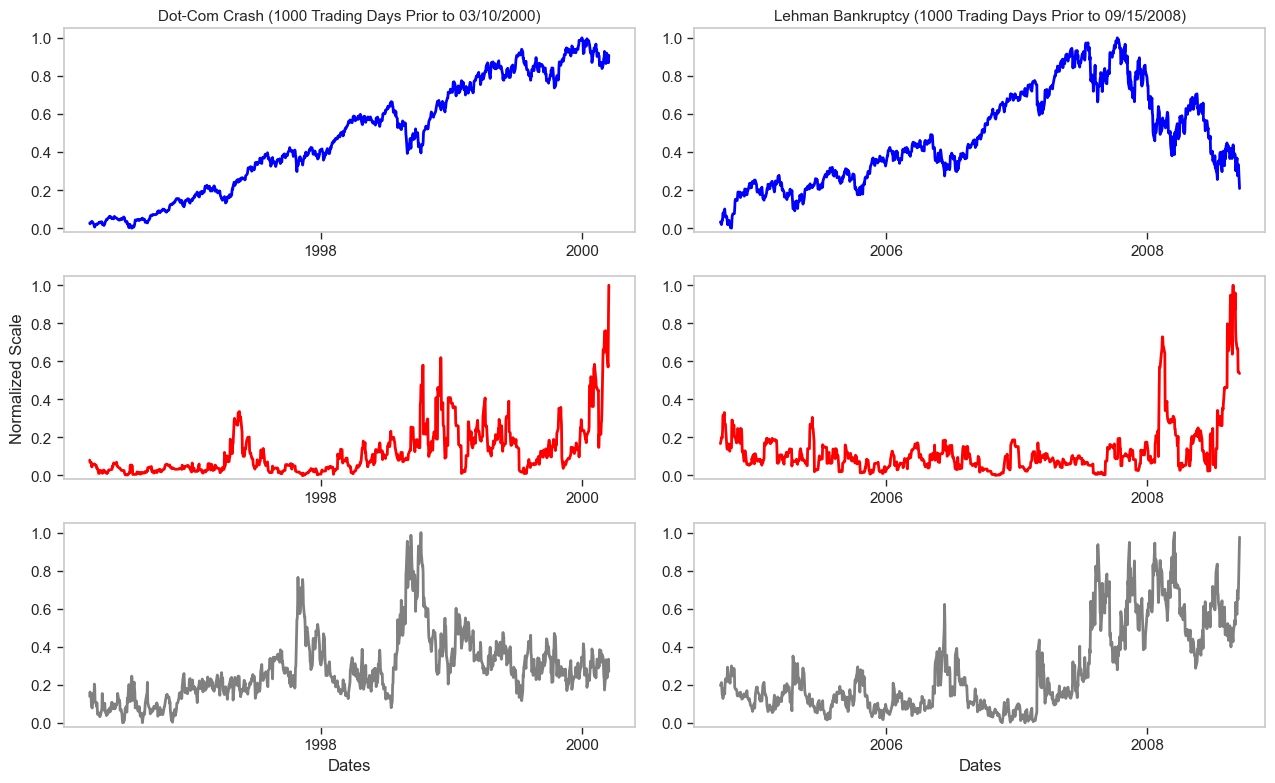

In [10]:
vix = yf.download('^VIX', start='1992-01-01', end='2016-12-09', progress=False)['Close']
vix_series = vix.iloc[:, 0]

sp500_price = df['SP500']

plot_dates = dates[50:]
sp500_aligned = sp500_price.loc[plot_dates]
vix_aligned = vix_series.loc[plot_dates]

mask_dotcom = get_1000_days_prior(plot_dates, '2000-03-15')
mask_lehman = get_1000_days_prior(plot_dates, '2008-09-15')

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharey=False)

dates_dotcom = plot_dates[mask_dotcom]

axes[0, 0].plot(
    dates_dotcom,
    min_max_scale(sp500_aligned[mask_dotcom]),
    color='blue',
    linewidth=2,
)
axes[0, 0].set_title(
    "Dot-Com Crash (1000 Trading Days Prior to 03/10/2000)", fontsize=11
)

axes[1, 0].plot(
    dates_dotcom,
    min_max_scale(p1_50days[mask_dotcom]),
    color='red',
    linewidth=2,
)
axes[1, 0].set_ylabel('Normalized Scale', fontsize=12)

axes[2, 0].plot(
    dates_dotcom,
    min_max_scale(vix_aligned[mask_dotcom]),
    color='gray',
    linewidth=2,
)
axes[2, 0].set_xlabel('Dates', fontsize=12)

dates_lehman = plot_dates[mask_lehman]

axes[0, 1].plot(
    dates_lehman,
    min_max_scale(sp500_aligned[mask_lehman]),
    color='blue',
    linewidth=2,
)
axes[0, 1].set_title(
    "Lehman Bankruptcy (1000 Trading Days Prior to 09/15/2008)", fontsize=11
)

axes[1, 1].plot(
    dates_lehman,
    min_max_scale(p1_50days[mask_lehman]),
    color='red',
    linewidth=2,
)

axes[2, 1].plot(
    dates_lehman,
    min_max_scale(vix_aligned[mask_lehman]),
    color='gray',
    linewidth=2,
)
axes[2, 1].set_xlabel('Dates', fontsize=12)

for ax in axes.flat:
    ax.tick_params(bottom=True, left=True, length=5, width=1.0)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

The following observations can be made.
1. **Early Phase Warning**: In both crisis events, $L^1$ persistence landscape norms exhibit sustained upward trends before the index price reaches its final peak or crashes.
2. **Topological Lead vs. Market Volatility**: While the VIX remains low during equity rally phases (reflecting market complacency), PL norms steadily rise as return vectors begin to disperse, demonstrating that TDA captures multi-index geometric shifts before traditional volatility indices react.
3. **Practical Scope and Limitations**: While PL norms clearly spike prior to major market corrections, distinguishing pre-crash signals from transitory volatility bumps remains a practical challenge for real-time market timing.

#### **Early Warning Signal Analysis**

In complex dynamical systems that approach a tipping point, a phenomenon known as **Critical Slowing Down (CSD)** occurs: the system's recovery rate from small external perturbations slows down dramatically. To test whether PL norms can detect CSD in financial markets, we evaluate three standard early warning indicators over a 250 trading day window prior to each crash using a rolling 500-day statistical window. We expect all three measures *(variance, low frequency spectral density, and autocorrelation at lag-1)* to increase prior to a crash.

We measure trend strength using the non-parametric *Kendall-$\tau$ rank correlation coefficient* ($\tau \in [-1, 1]$), where positive values ($\tau > 0$, $p < 0.05$) indicate statistically significant monotonically increasing early warning signals.

We attempt to reproduce findings from Figure 11 of the paper twice, first without linear detrending and thereafter with. The figure consists of two parts, (a) representing dot-com crash and (b) Lehman Brothers' bankrupcy. First row in each parts represents computed measures on time-series of norms, whereas second row represents the same process but for VIX.

Dot-Com Crash (2000-03-10):
L1 Variance           τ = -0.2286  (p = 0.0000)
L2 Variance           τ = -0.4002  (p = 0.0000)
L1 Spectrum           τ = +0.9184  (p = 0.0000)
L2 Spectrum           τ = +0.8752  (p = 0.0000)
L1 ACF(1)             τ = -0.7834  (p = 0.0000)
L2 ACF(1)             τ = -0.8129  (p = 0.0000)
VIX Variance          τ = -0.8347  (p = 0.0000)
VIX Spectrum          τ = -0.5279  (p = 0.0000)
VIX ACF(1)            τ = -0.8743  (p = 0.0000)

Lehman Bankruptcy (2008-09-15):
L1 Variance           τ = +0.8885  (p = 0.0000)
L2 Variance           τ = +0.9560  (p = 0.0000)
L1 Spectrum           τ = +0.7841  (p = 0.0000)
L2 Spectrum           τ = +0.7954  (p = 0.0000)
L1 ACF(1)             τ = +0.4179  (p = 0.0000)
L2 ACF(1)             τ = +0.4041  (p = 0.0000)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)


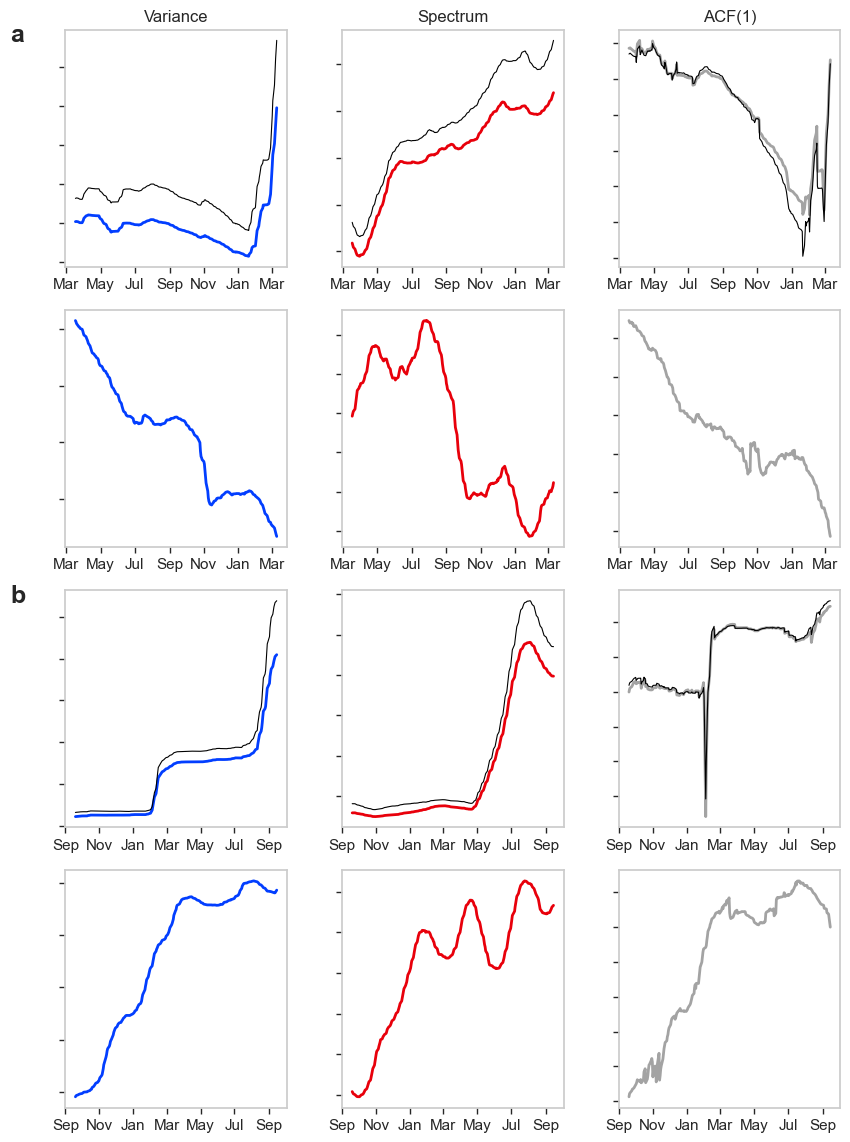

In [11]:
vix_series = (
    vix.reindex(dates_50).ffill().bfill()
    if not isinstance(vix, pd.Series)
    else vix.reindex(dates_50).ffill().bfill()
)
vix_vals = (
    vix_series.iloc[:, 0].values
    if isinstance(vix_series, pd.DataFrame)
    else vix_series.values
)
vix_scaled = vix_vals / 100.0

d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days, dates_50, '2000-03-10', detrend_win=False)
_,   v2_a, acf2_a, spec2_a = compute_indicators(p2_50days, dates_50, '2000-03-10', detrend_win=False)
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators(vix_scaled, dates_50, '2000-03-10', detrend_win=False)

d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days, dates_50, '2008-09-15', detrend_win=False)
_,   v2_b, acf2_b, spec2_b = compute_indicators(p2_50days, dates_50, '2008-09-15', detrend_win=False)
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators(vix_scaled, dates_50, '2008-09-15', detrend_win=False)

if inspect_output:
    print("Dot-Com Crash (2000-03-10):")
    for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                    ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                    ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                    ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                    ('VIX ACF(1)', vix_acf_a)]:
        kendall_report(name, vals)

    print("\nLehman Bankruptcy (2008-09-15):")
    for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                    ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                    ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                    ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                    ('VIX ACF(1)', vix_acf_b)]:
        kendall_report(name, vals)

fig = plt.figure(figsize=(10, 14))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

ax_a_v_land.plot(d_a, v2_a, color=colors[0], lw=2.0)
ax_a_v_land.plot(d_a, v1_a, 'black', lw=0.8)
ax_a_v_land.set_title('Variance')
ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec2_a, color=colors[3], lw=2.0)
ax_a_s_land.plot(d_a, spec1_a, 'black', lw=0.8)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf2_a, color=colors[7], lw=2.0)
ax_a_a_land.plot(d_a, acf1_a, 'black', lw=0.8)
ax_a_a_land.set_title('ACF(1)')

ax_a_v_vix.plot(d_a, vix_v_a, color=colors[0], lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, color=colors[3], lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, color=colors[7], lw=2.0)

ax_b_v_land.plot(d_b, v2_b, color=colors[0], lw=2.0)
ax_b_v_land.plot(d_b, v1_b, 'black', lw=0.8)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec2_b, color=colors[3], lw=2.0)
ax_b_s_land.plot(d_b, spec1_b, 'black', lw=0.8)
ax_b_a_land.plot(d_b, acf2_b, color=colors[7], lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, 'black', lw=0.8)

ax_b_v_vix.plot(d_b, vix_v_b, color=colors[0], lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, color=colors[3], lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, color=colors[7], lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_yticklabels([])

plt.show()

**Dot-Com Bubble Crash:**
Without any detrending, we observe a positive significant trend for spectrum (as the paper suggest) across both norms. However, we do also observe significant negative trends for variance and ACF, which deviate from the paper's findings. Furthermore, VIX has a significant negative trend across all three measures.

**Lehman Bankruptcy:**
We see significant positive trends across all measures, which is also the case for VIX. This matches the paper's findings.

Note that the overall shape of the graphs deduced without any detrending resembles Figure 11 from the paper closely.

Dot-Com Crash (2000-03-10):
L1 Variance           τ = +0.6824  (p = 0.0000)
L2 Variance           τ = +0.6643  (p = 0.0000)
L1 Spectrum           τ = +0.8620  (p = 0.0000)
L2 Spectrum           τ = +0.8427  (p = 0.0000)
L1 ACF(1)             τ = +0.0721  (p = 0.0894)
L2 ACF(1)             τ = +0.1523  (p = 0.0003)
VIX Variance          τ = -0.8347  (p = 0.0000)
VIX Spectrum          τ = -0.5279  (p = 0.0000)
VIX ACF(1)            τ = -0.8743  (p = 0.0000)

Lehman Bankruptcy (2008-09-15):
L1 Variance           τ = +0.7992  (p = 0.0000)
L2 Variance           τ = +0.9167  (p = 0.0000)
L1 Spectrum           τ = +0.8443  (p = 0.0000)
L2 Spectrum           τ = +0.8467  (p = 0.0000)
L1 ACF(1)             τ = +0.2569  (p = 0.0000)
L2 ACF(1)             τ = +0.2483  (p = 0.0000)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)


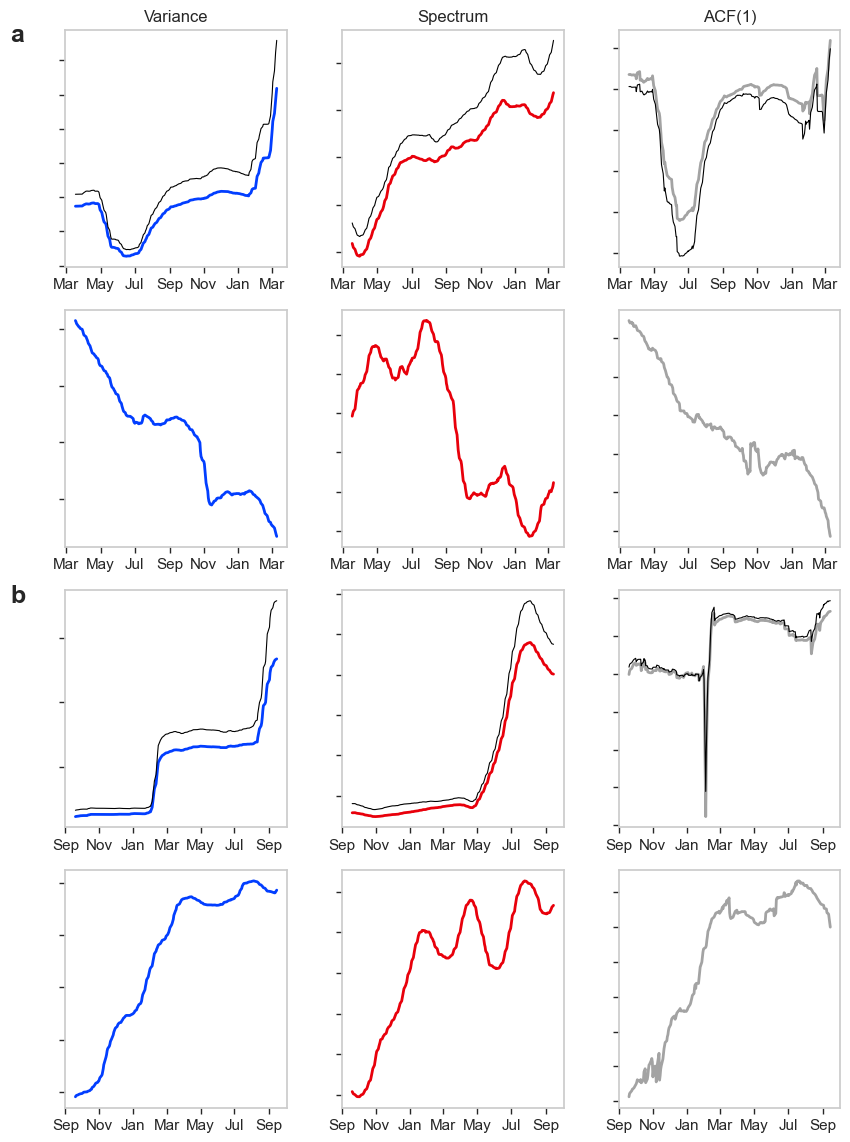

In [12]:
d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days, dates_50, '2000-03-10', detrend_win=True)
_,   v2_a, acf2_a, spec2_a = compute_indicators(p2_50days, dates_50, '2000-03-10', detrend_win=True)
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators(vix_scaled, dates_50, '2000-03-10', detrend_win=False)

d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days, dates_50, '2008-09-15', detrend_win=True)
_,   v2_b, acf2_b, spec2_b = compute_indicators(p2_50days, dates_50, '2008-09-15', detrend_win=True)
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators(vix_scaled, dates_50, '2008-09-15', detrend_win=False)

if inspect_output:
    print("Dot-Com Crash (2000-03-10):")
    for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                    ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                    ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                    ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                    ('VIX ACF(1)', vix_acf_a)]:
        kendall_report(name, vals)

    print("\nLehman Bankruptcy (2008-09-15):")
    for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                    ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                    ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                    ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                    ('VIX ACF(1)', vix_acf_b)]:
        kendall_report(name, vals)

fig = plt.figure(figsize=(10, 14))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

ax_a_v_land.plot(d_a, v2_a, color=colors[0], lw=2.0)
ax_a_v_land.plot(d_a, v1_a, 'black', lw=0.8)
ax_a_v_land.set_title('Variance')
ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec2_a, color=colors[3], lw=2.0)
ax_a_s_land.plot(d_a, spec1_a, 'black', lw=0.8)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf2_a, color=colors[7], lw=2.0)
ax_a_a_land.plot(d_a, acf1_a, 'black', lw=0.8)
ax_a_a_land.set_title('ACF(1)')

ax_a_v_vix.plot(d_a, vix_v_a, color=colors[0], lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, color=colors[3], lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, color=colors[7], lw=2.0)

ax_b_v_land.plot(d_b, v2_b, color=colors[0], lw=2.0)
ax_b_v_land.plot(d_b, v1_b, 'black', lw=0.8)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec2_b, color=colors[3], lw=2.0)
ax_b_s_land.plot(d_b, spec1_b, 'black', lw=0.8)
ax_b_a_land.plot(d_b, acf2_b, color=colors[7], lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, 'black', lw=0.8)

ax_b_v_vix.plot(d_b, vix_v_b, color=colors[0], lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, color=colors[3], lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, color=colors[7], lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_yticklabels([])

plt.show()

**Dot-Com Bbubble Crash:**
With detrending, we observe positive significant trends for all measures except $L^1$ of ACF which has a p-value of $8.94\%$. This does match the paper's findings.

**Lehman Bankrupcy:**
We also see significant positive trends across all measures.

Caveat for linear detrending is that the graphs slightly deviate from Figure 11. Most notable example is top right graph (ACF), but minor differences can be observed for other trends as well.

Overall, we attribute these differences primarily due to sensitivity of measures to previous crises (such as Russia's 1998 financial crisis). Future research of TDA on CSD prediction could investigate matters of robustness.

## **Detour: Persistence Images as an Alternative to Landscapes**

We extend the original paper to compare the effect of choosing **Persistence Images** (Adams, 2017) as a form of representation. Since PIs require choosing parameters (mainly variance and resolution), we begin by evaluating a grid of candidate hyperparameters. Furthermore, instead of $L^2$ norm we compute $L^\infty$ as $L^1 = L^2$ after min-max rescaling.

In [13]:
from core.representations import PersistenceImage
from core.persistence import rips_filtration, PersistenceDiagram

In [14]:
def precompute_time_series_pds(data, window_sizes, dim=1):
    rows = data.shape[0]
    pds_dict = {}

    for w in window_sizes:
        size = rows - w
        pds = []
        for i in range(size):
            pc = data[i:(i + w), :]
            rips = rips_filtration(pc, max_dim=dim, use_ripser=True)
            pd = PersistenceDiagram()
            for pair in rips.extract_pairs():
                if pair.dim == dim:
                    pd.add_pair(pair)
            pds.append(pd)
        pds_dict[w] = pds

    return pds_dict


def compute_pi_norms_from_pds(pds_dict, sigma, resolution, dim=1):
    norm_series = []

    for w, pds in pds_dict.items():
        all_births = []
        all_persistences = []
        for pd in pds:
            for pair in pd.pairs_by_dim(dim):
                if not pair.is_infinite():
                    all_births.append(pair.birth)
                    all_persistences.append(pair.death - pair.birth)

        if len(all_births) == 0:
            global_bounds = ((0, 1), (0, 1))
            max_persistence = 1.0
        else:
            global_bounds = (
                (min(all_births) - sigma, max(all_births) + sigma),
                (0, max(all_persistences) + sigma)
            )
            max_persistence = max(all_persistences)

        size = len(pds)
        p1_series = np.zeros(size)
        pinf_series = np.zeros(size)

        for i, pd in enumerate(pds):
            pi = PersistenceImage(
                pd, 
                sigma=sigma, 
                resolution=resolution, 
                homology_dim=dim, 
                bounds=global_bounds, 
                max_b=max_persistence
            )
            p1_series[i] = pi.norm(p=1)
            pinf_series[i] = pi.norm(p=np.inf)

        norm_series.append((p1_series, pinf_series))

    return norm_series

In [15]:
pds_dict = precompute_time_series_pds(returns, window_sizes=[50, 100], dim=1)

grid_results = {}
for res in [(10, 10), (20, 20), (50, 50)]:
    for sig in [0.01, 0.05, 0.10, 0.20]:
        tau_scores = []

        norms = compute_pi_norms_from_pds(pds_dict, sigma=sig, resolution=res, dim=1)
        (p1_50days_pi, _), (p1_100days_pi, _) = norms[0], norms[1]
        
        _, v50_a, acf50_a, spec50_a = compute_indicators(p1_50days_pi, dates_50, '2000-03-10', detrend_win=False)
        _, v100_a, acf100_a, spec100_a = compute_indicators(p1_100days_pi, dates_100, '2000-03-10', detrend_win=False)

        _, v50_b, acf50_b, spec50_b = compute_indicators(p1_50days_pi, dates_50, '2008-09-15', detrend_win=False)
        _, v100_b, acf100_b, spec100_b = compute_indicators(p1_100days_pi, dates_100, '2008-09-15', detrend_win=False)
            
        for vals in [v50_a, acf50_a, spec50_a, v100_a, acf100_a, spec100_a,
                           v50_b, acf50_b, spec50_b, v100_b, acf100_b, spec100_b]:

            tau, p_val = kendalltau(np.arange(len(vals)), vals)
            if p_val < 0.05 and tau > 0:
                tau_scores.append(1.0)
            else:
                tau_scores.append(0.0)
                
        grid_results[(res, sig)] = np.mean(tau_scores)


for config, score in sorted(grid_results.items(), key=lambda x: x[1], reverse=True):
    print(f"Resolution: {config[0]}, Sigma: {config[1]} | EWS Pass Rate: {score:.1%}")

Resolution: (10, 10), Sigma: 0.01 | EWS Pass Rate: 58.3%
Resolution: (10, 10), Sigma: 0.05 | EWS Pass Rate: 58.3%
Resolution: (10, 10), Sigma: 0.1 | EWS Pass Rate: 58.3%
Resolution: (10, 10), Sigma: 0.2 | EWS Pass Rate: 58.3%
Resolution: (20, 20), Sigma: 0.01 | EWS Pass Rate: 58.3%
Resolution: (20, 20), Sigma: 0.05 | EWS Pass Rate: 58.3%
Resolution: (20, 20), Sigma: 0.1 | EWS Pass Rate: 58.3%
Resolution: (20, 20), Sigma: 0.2 | EWS Pass Rate: 58.3%
Resolution: (50, 50), Sigma: 0.01 | EWS Pass Rate: 58.3%
Resolution: (50, 50), Sigma: 0.05 | EWS Pass Rate: 58.3%
Resolution: (50, 50), Sigma: 0.1 | EWS Pass Rate: 58.3%
Resolution: (50, 50), Sigma: 0.2 | EWS Pass Rate: 58.3%


Note that parameter choice has no effect on EWS, which is consistent with the results from (Adams, 2017). We proceed with using $\sigma=0.05$ and resolution of $(20,20)$ for the rest of the section.

Next, we apply the usual pipeline to compute time series of PI norms and plot through the entire period.

In [16]:
def compute_time_series_image_norms(data, window_size, sigma, resolution, dim=1):
    rows = data.shape[0]
    norm_series = []
    for w in window_size:
        size = rows - w
        
        pds = []
        all_births = []
        all_persistences = []
        for i in range(size):
            pc = data[i:(i + w), :]
            rips = rips_filtration(pc, max_dim=dim, use_ripser=True)
            pd = PersistenceDiagram()
            
            for pair in rips.extract_pairs():
                if pair.dim == dim:
                    pd.add_pair(pair)
                    all_births.append(pair.birth)
                    all_persistences.append(pair.death - pair.birth)
            pds.append(pd)

        global_bounds = (
            (min(all_births) - sigma, max(all_births) + sigma),
            (0, max(all_persistences) + sigma)
        )
        max_persistence = max(all_persistences)

        p1_series = np.zeros(size)
        pinf_series = np.zeros(size)
        for i, pd in enumerate(pds):
            pi = PersistenceImage(pd, sigma=sigma, resolution=resolution, homology_dim=dim,
                                 bounds=global_bounds, max_b=max_persistence)
            p1_series[i] = pi.norm(1)
            pinf_series[i] = pi.norm(np.inf)
        norm_series.append((p1_series, pinf_series))

    return norm_series

(p1_50days_pi, pinf_50days_pi), (p1_100days_pi, pinf_100days_pi) = compute_time_series_image_norms(
    returns, window_size, 0.05, (20,20)
)

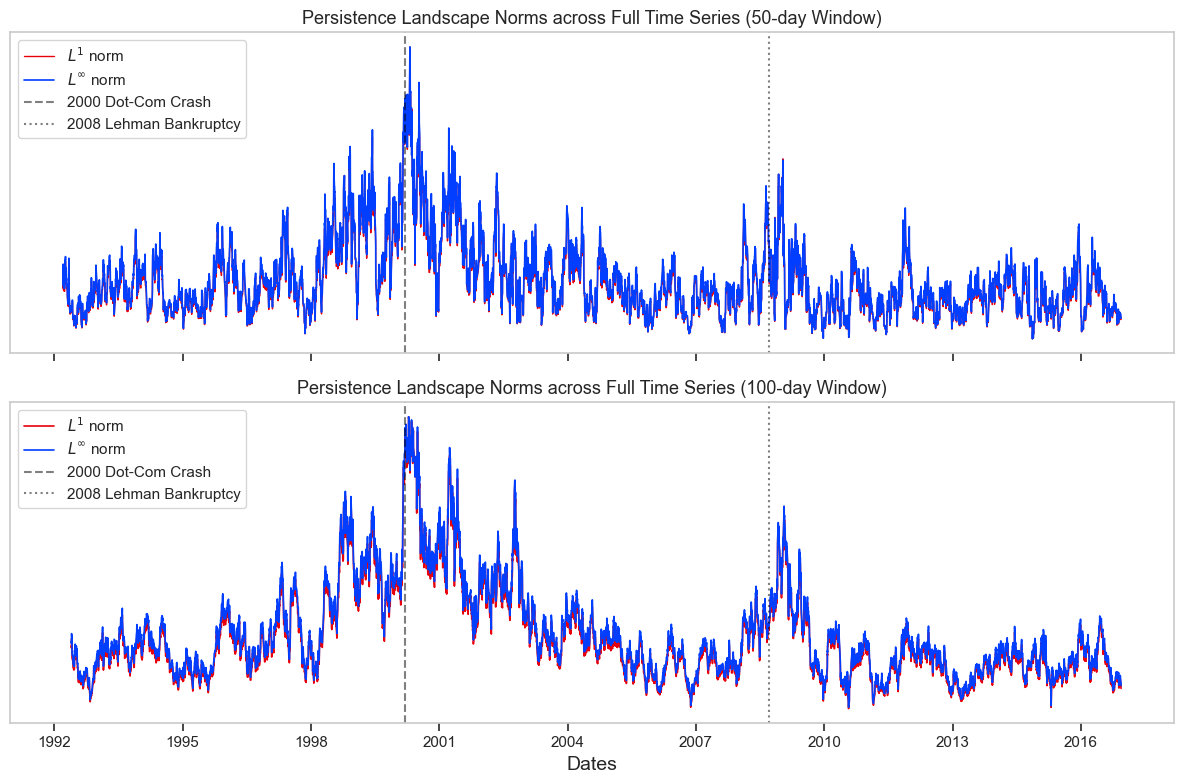

In [17]:
p1_50days_pi = p1_50days_pi / np.max(p1_50days_pi)
pinf_50days_pi = pinf_50days_pi / np.max(pinf_50days_pi)
p1_100days_pi = p1_100days_pi / np.max(p1_100days_pi)
pinf_100days_pi = pinf_100days_pi / np.max(pinf_100days_pi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(
    dates[50:],
    p1_50days_pi,
    color=colors[3],
    linewidth=1,
    label='$L^1$ norm',
)

ax1.plot(
    dates[50:],
    pinf_50days_pi,
    color=colors[0],
    linewidth=1.2,
    label=r'$L^\infty$ norm',
)

ax1.axvline(
    x=pd.Timestamp('2000-03-10'),
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.5,
    label='2000 Dot-Com Crash',
)
ax1.axvline(
    x=pd.Timestamp('2008-09-15'),
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.5,
    label='2008 Lehman Bankruptcy',
)

ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.set_yticks([])
ax1.set_title(
    'Persistence Landscape Norms across Full Time Series (50-day Window)',
    fontsize=13,
)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax1.legend(fontsize=11, loc='upper left')


ax2.plot(
    dates[100:],
    p1_100days_pi,
    color=colors[3],
    linewidth=1.2,
    label='$L^1$ norm',
)

ax2.plot(
    dates[100:],
    pinf_100days_pi,
    color=colors[0],
    linewidth=1.2,
    label=r'$L^\infty$ norm',
)

ax2.axvline(
    x=pd.Timestamp('2000-03-10'),
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.5,
    label='2000 Dot-Com Crash',
)
ax2.axvline(
    x=pd.Timestamp('2008-09-15'),
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.5,
    label='2008 Lehman Bankruptcy',
)

ax2.set_xlabel('Dates', fontsize=14)
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.set_yticks([])
ax2.set_title(
    'Persistence Landscape Norms across Full Time Series (100-day Window)',
    fontsize=13,
)

ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

We observe that there is virtually no difference between the norms. Furthermore, the time series across both windows seem more dispersed when compared to PL norms. This could be problematic as previous, smaller financial crises could reduce the signal of upcoming, bigger meltdowns.

As in Section 4, we proceed by computing the main measures to predict CSD.

Dot-Com Crash (2000-03-10):
L1 Variance           τ = -0.3133  (p = 0.0000)
L2 Variance           τ = -0.3092  (p = 0.0000)
L1 Spectrum           τ = +0.7630  (p = 0.0000)
L2 Spectrum           τ = +0.7497  (p = 0.0000)
L1 ACF(1)             τ = -0.5133  (p = 0.0000)
L2 ACF(1)             τ = -0.5026  (p = 0.0000)
VIX Variance          τ = -0.8347  (p = 0.0000)
VIX Spectrum          τ = -0.5279  (p = 0.0000)
VIX ACF(1)            τ = -0.8743  (p = 0.0000)

Lehman Bankruptcy (2008-09-15):
L1 Variance           τ = +0.6433  (p = 0.0000)
L2 Variance           τ = +0.6154  (p = 0.0000)
L1 Spectrum           τ = +0.7953  (p = 0.0000)
L2 Spectrum           τ = +0.7914  (p = 0.0000)
L1 ACF(1)             τ = +0.3728  (p = 0.0000)
L2 ACF(1)             τ = +0.3685  (p = 0.0000)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)


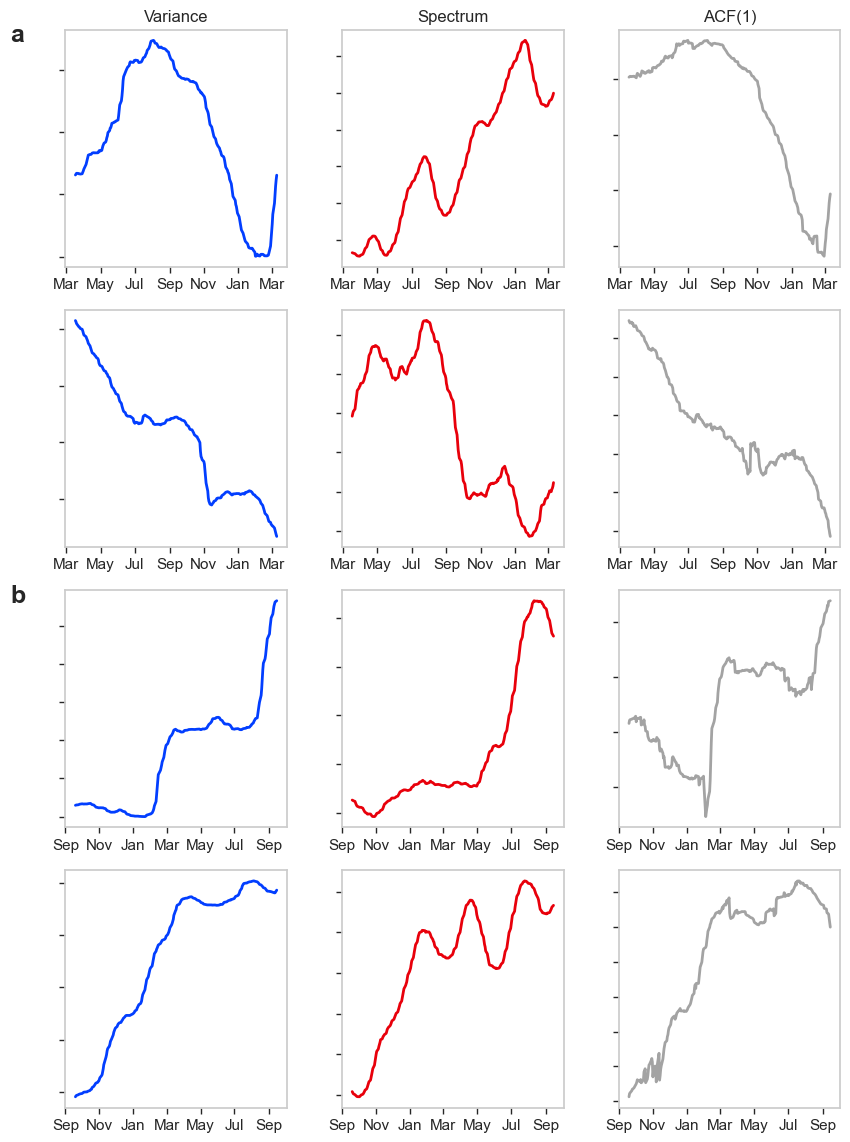

In [18]:
d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days_pi, dates_50, '2000-03-10', detrend_win=False)
_,   v2_a, acf2_a, spec2_a = compute_indicators(pinf_50days_pi, dates_50, '2000-03-10', detrend_win=False)
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators(vix_scaled, dates_50, '2000-03-10', detrend_win=False)

d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days_pi, dates_50, '2008-09-15', detrend_win=False)
_,   v2_b, acf2_b, spec2_b = compute_indicators(pinf_50days_pi, dates_50, '2008-09-15', detrend_win=False)
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators(vix_scaled, dates_50, '2008-09-15', detrend_win=False)

if inspect_output:
    print("Dot-Com Crash (2000-03-10):")
    for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                    ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                    ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                    ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                    ('VIX ACF(1)', vix_acf_a)]:
        kendall_report(name, vals)

    print("\nLehman Bankruptcy (2008-09-15):")
    for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                    ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                    ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                    ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                    ('VIX ACF(1)', vix_acf_b)]:
        kendall_report(name, vals)

fig = plt.figure(figsize=(10, 14))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

ax_a_v_land.plot(d_a, v1_a, color=colors[0], lw=2.0)
ax_a_v_land.set_title('Variance')
ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec1_a, color=colors[3], lw=2.0)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf1_a, color=colors[7], lw=2.0)
ax_a_a_land.set_title('ACF(1)')

ax_a_v_vix.plot(d_a, vix_v_a, color=colors[0], lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, color=colors[3], lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, color=colors[7], lw=2.0)

ax_b_v_land.plot(d_b, v1_b, color=colors[0], lw=2.0)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec1_b, color=colors[3], lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, color=colors[7], lw=2.0)

ax_b_v_vix.plot(d_b, vix_v_b, color=colors[0], lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, color=colors[3], lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, color=colors[7], lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_yticklabels([])

plt.show()

Dot-Com Crash (2000-03-10):
L1 Variance           τ = +0.3407  (p = 0.0000)
L2 Variance           τ = +0.3236  (p = 0.0000)
L1 Spectrum           τ = +0.7661  (p = 0.0000)
L2 Spectrum           τ = +0.7577  (p = 0.0000)
L1 ACF(1)             τ = -0.0703  (p = 0.0976)
L2 ACF(1)             τ = -0.0796  (p = 0.0609)
VIX Variance          τ = -0.8347  (p = 0.0000)
VIX Spectrum          τ = -0.5279  (p = 0.0000)
VIX ACF(1)            τ = -0.8743  (p = 0.0000)

Lehman Bankruptcy (2008-09-15):
L1 Variance           τ = +0.4078  (p = 0.0000)
L2 Variance           τ = +0.4025  (p = 0.0000)
L1 Spectrum           τ = +0.8336  (p = 0.0000)
L2 Spectrum           τ = +0.8277  (p = 0.0000)
L1 ACF(1)             τ = +0.1061  (p = 0.0125)
L2 ACF(1)             τ = +0.0978  (p = 0.0213)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)


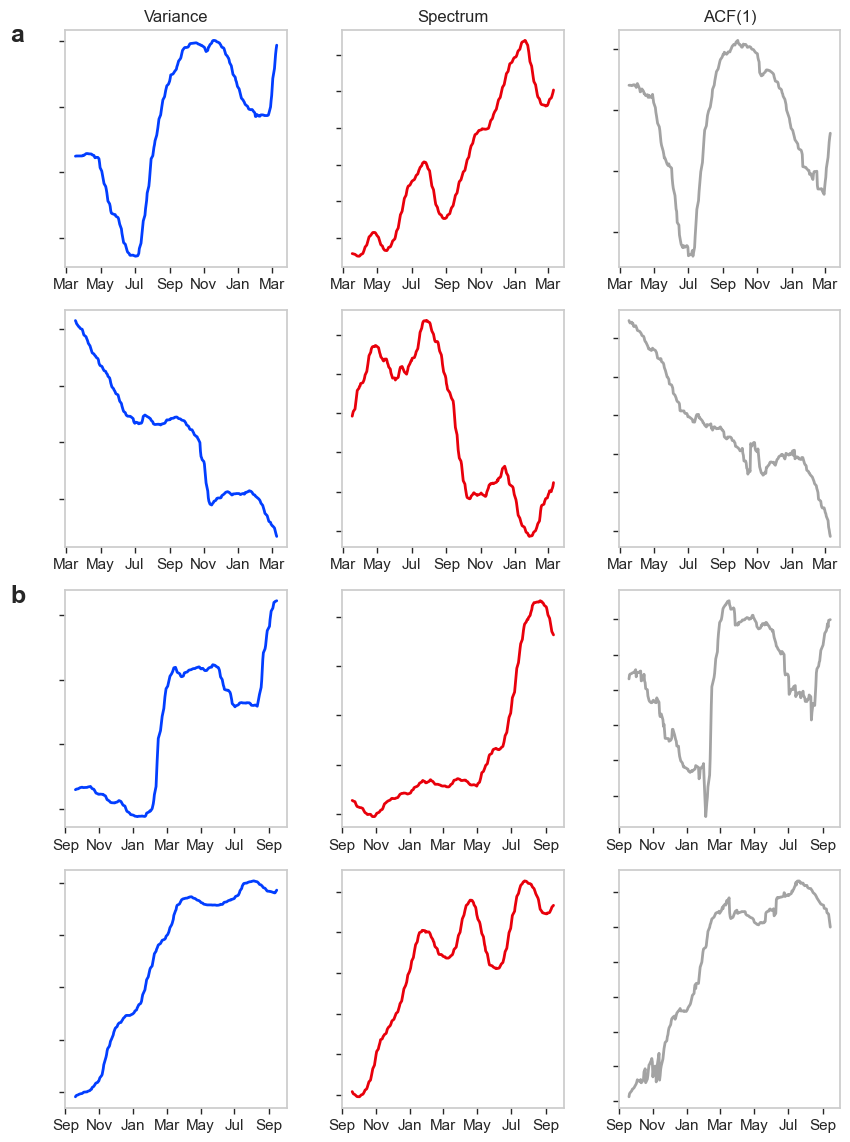

In [19]:
d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days_pi, dates_50, '2000-03-10', detrend_win=True)
_,   v2_a, acf2_a, spec2_a = compute_indicators(pinf_50days_pi, dates_50, '2000-03-10', detrend_win=True)
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators(vix_scaled, dates_50, '2000-03-10', detrend_win=False)

d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days_pi, dates_50, '2008-09-15', detrend_win=True)
_,   v2_b, acf2_b, spec2_b = compute_indicators(pinf_50days_pi, dates_50, '2008-09-15', detrend_win=True)
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators(vix_scaled, dates_50, '2008-09-15', detrend_win=False)

if inspect_output:
    print("Dot-Com Crash (2000-03-10):")
    for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                    ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                    ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                    ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                    ('VIX ACF(1)', vix_acf_a)]:
        kendall_report(name, vals)

    print("\nLehman Bankruptcy (2008-09-15):")
    for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                    ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                    ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                    ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                    ('VIX ACF(1)', vix_acf_b)]:
        kendall_report(name, vals)

fig = plt.figure(figsize=(10, 14))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

ax_a_v_land.plot(d_a, v1_a, color=colors[0], lw=2.0)
ax_a_v_land.set_title('Variance')
ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec1_a, color=colors[3], lw=2.0)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf1_a, color=colors[7], lw=2.0)
ax_a_a_land.set_title('ACF(1)')

ax_a_v_vix.plot(d_a, vix_v_a, color=colors[0], lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, color=colors[3], lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, color=colors[7], lw=2.0)

ax_b_v_land.plot(d_b, v1_b, color=colors[0], lw=2.0)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec1_b, color=colors[3], lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, color=colors[7], lw=2.0)

ax_b_v_vix.plot(d_b, vix_v_b, color=colors[0], lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, color=colors[3], lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, color=colors[7], lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_yticklabels([])

plt.show()

The results are consistent with persistence landscapes, which suggests that there are no clear advantages over using persistence images. Future research direction could explore the usage of different weighing functions and norms for persistence images to see whether these results could be improved.